## 1. 

| Question | Assumed answer |
|---|---|
| What's the daily customer/demand distribution? | Roughly symmetric around 50 kg/day |
| Selling price and purchase cost per kg? | Sell $20/kg, buy $10/kg |
| Is there a cost to holding unsold fish overnight? | Yes. $2/kg shelf space/quality-degradation |
| In what increments can she order? | 10kg |
| Does demand vary by day of week / season? | Assume no |
| What's the planning horizon? | 20 days, with leftover fish on the last day salvaged at the sale price |
| How risk-tolerant is she? | Depends on business type  |


## 2. 

**State** `S = (s1, s2)`:
- `s1` = fish carried over from the previous day (still sellable today)
- `s2` = fish sold the previous day 

**Control**: `purchase` = kgs of fresh fish bought today 

**Reward** (daily profit):
```
profit = price × (yesterday's sales)  −  cost × (today's purchase)  −  holdcost × (today's carryover)
```

**State transition** (given today's demand realisation `d`, oldest stock sold first):
- If `d < s1`: demand fully met from old stock; the unsold remainder of `s1`
  is too old and discarded; `sold = d`; new carryover = today's `purchase`
  (all still fresh)
- If `s1 ≤ d < s1+purchase`: old stock used up, some of today's purchase also
  sells; `sold = d`; new carryover = `s1+purchase−d`
- If `d ≥ s1+purchase`: everything sells; `sold = s1+purchase`; new carryover = 0

This is a 2-period-shelf-life inventory problem, solved by discrete DP
(backward induction) over a finite 20-day horizon.


### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gridmake(s1, s2):
    # matches CompEcon's gridmake: s1 varies fastest (column-major stacking)
    S1, S2 = np.meshgrid(s1, s2, indexing='ij')
    return np.column_stack([S1.ravel(order='F'), S2.ravel(order='F')])


### Core solver


In [2]:
def solve_sushi_dp(price=20, cost=10, holdcost=2, T=20,
                    demand_vals=None, prob=None, target=None, lam=0.0):
    if demand_vals is None:
        demand_vals = 50 + 10*np.arange(-2, 3)          # {30,40,50,60,70}
    demand_vals = np.asarray(demand_vals)
    if prob is None:
        prob = np.ones_like(demand_vals, dtype=float)
    prob = np.asarray(prob, dtype=float)
    prob = prob / prob.sum()

    maxdemand = demand_vals.max()
    s1 = np.arange(0, maxdemand + 1, 10)                # carryover levels
    s2 = np.arange(0, maxdemand + 1, 10)                # yesterday's sales levels
    S = gridmake(s1, s2)
    n = S.shape[0]
    purchase = np.arange(0, maxdemand + 1, 10)          # 10-lb purchase lots
    m = len(purchase)

    idx_lookup = {(int(r[0]), int(r[1])): i for i, r in enumerate(S)}

    # Reward matrix (n x m): dollar profit for each state/action pair
    f_profit = (price * S[:, 1][:, None] * np.ones((1, m))
                - cost * np.ones((n, 1)) * purchase[None, :]
                - holdcost * S[:, 0][:, None] * np.ones((1, m)))

    if target is not None and lam:
        shortfall = np.maximum(0.0, target - f_profit)
        f = f_profit - lam * shortfall**2               # risk-averse utility
    else:
        f = f_profit                                    # risk-neutral profit

    # Transition tensor: P[a] is n x n (probability of landing in each next state)
    P = np.zeros((m, n, n))
    for j, purch in enumerate(purchase):
        for i in range(n):
            carry_i = S[i, 0]
            for k, d in enumerate(demand_vals):
                if d < carry_i:
                    new_carry, sold = purch, d
                elif d < carry_i + purch:
                    new_carry, sold = carry_i + purch - d, d
                else:
                    new_carry, sold = 0, carry_i + purch
                l = idx_lookup[(int(new_carry), int(sold))]
                P[j, i, l] += prob[k]

    # Backward induction over the finite horizon
    vterm = price * S[:, 1]                             # salvage value at T
    J = np.zeros((n, T + 1))
    u = np.zeros((n, T), dtype=int)
    J[:, T] = vterm
    for t in range(T - 1, -1, -1):
        vals = f + np.stack([P[a] @ J[:, t + 1] for a in range(m)], axis=1)
        u[:, t] = np.argmax(vals, axis=1)
        J[:, t] = np.max(vals, axis=1)

    return dict(S=S, s1=s1, s2=s2, purchase=purchase, J=J, u=u)


def plot_policy(result, itime=0, title=''):
    s1, s2, purchase, u = result['s1'], result['s2'], result['purchase'], result['u']
    uu = purchase[u[:, itime]].reshape(len(s1), len(s2), order='F')
    plt.figure(figsize=(6, 5))
    cs = plt.contourf(s1, s2, uu.T, levels=len(purchase))
    plt.colorbar(cs, label='Purchase amount (lb)')
    plt.xlabel('Fish carried over from the day before (lb)')
    plt.ylabel('Fish sold the day before (lb)')
    plt.title(title)
    plt.show()
    return uu


## 3. 


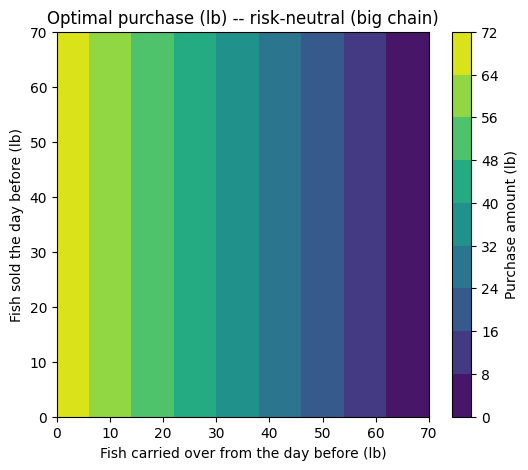

array([[70, 70, 70, 70, 70, 70, 70, 70],
       [60, 60, 60, 60, 60, 60, 60, 60],
       [50, 50, 50, 50, 50, 50, 50, 50],
       [40, 40, 40, 40, 40, 40, 40, 40],
       [30, 30, 30, 30, 30, 30, 30, 30],
       [20, 20, 20, 20, 20, 20, 20, 20],
       [10, 10, 10, 10, 10, 10, 10, 10],
       [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [3]:
result_chain = solve_sushi_dp()
uu_chain = plot_policy(result_chain, itime=0,
                        title='Optimal purchase (lb) -- risk-neutral (big chain)')
uu_chain


Purchase decreases roughly linearly as existing
carryover increases.
She buys just enough to bring total available stock (carryover + purchase) up
to a target level a bit above mean demand: since underage is costlier than overage, it pays to
lean slightly toward over-ordering. The policy is essentially flat, meaning that variable only matters for booking revenue, not for
deciding what to buy today.


## 4. 

A risk-neutral objective is incorrect for an owner who is fine
with enough to pay rent but stressed if she falls short.

We replace the reward with a **shortfall-penalised utility** around a target
daily profit `target` (rent + fixed costs):

```
utility(profit) = profit                          if profit >= target
                 = profit - lam*(target-profit)^2  if profit <  target
```

- `lam = 0` recovers the risk-neutral.
- Larger `lam` makes the DP increasingly averse to days that miss `target`,
  even at the cost of average profit.

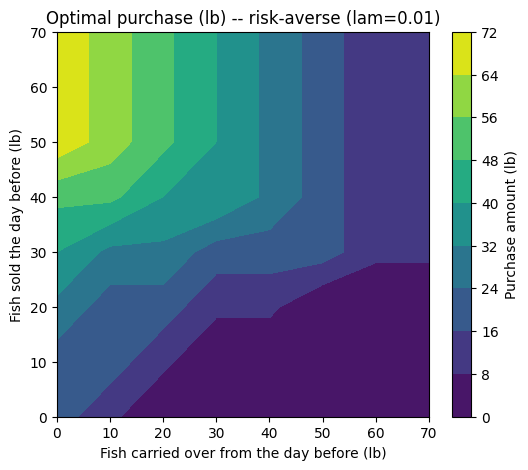

array([[20, 20, 30, 40, 50, 70, 70, 70],
       [10, 20, 20, 30, 50, 60, 60, 60],
       [ 0, 10, 20, 30, 40, 50, 50, 50],
       [ 0,  0, 10, 20, 40, 40, 40, 40],
       [ 0,  0, 10, 20, 30, 30, 30, 30],
       [ 0,  0,  0, 20, 20, 20, 20, 20],
       [ 0,  0,  0, 10, 10, 10, 10, 10],
       [ 0,  0,  0, 10, 10, 10, 10, 10]])

In [4]:
result_risk = solve_sushi_dp(target=300, lam=0.01)
uu_risk = plot_policy(result_risk, itime=0,
                       title='Optimal purchase (lb) -- risk-averse (lam=0.01)')
uu_risk


Unlike the risk-neutral case, the policy now
 depends on yesterday's sales as well as `s1`. Since
profit includes `price*s2`, whether yesterday was a good or bad sales day
changes how close today's expected profit is to the rent target and that
now feeds into how much to buy. In general the risk-averse policy is more
conservative and more state-dependent than the flat base-stock rule.
Whether it orders more or less depends on which risk dominates the
variance.

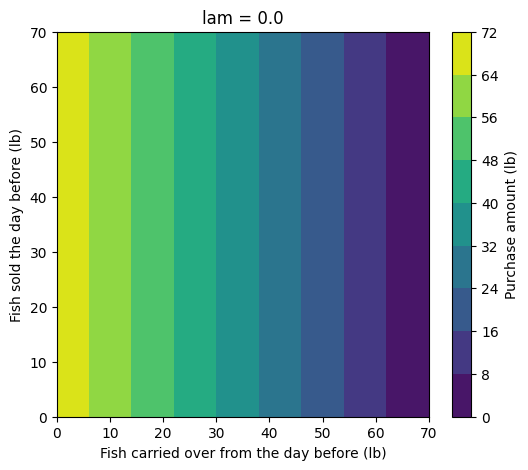

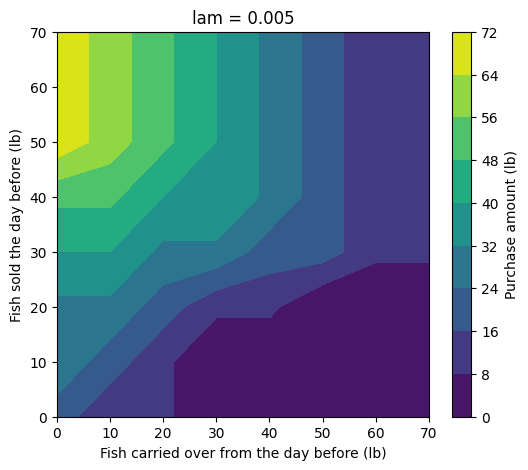

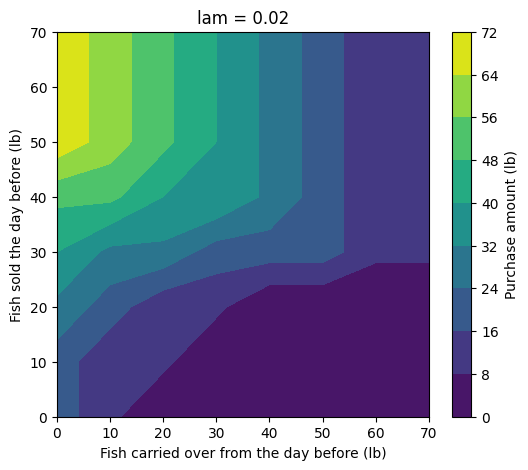

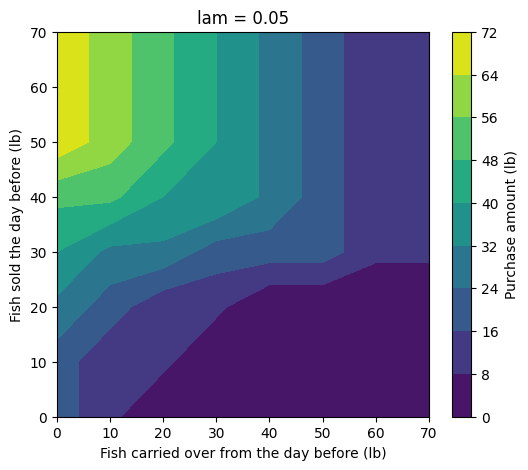

In [5]:
for lam in [0.0, 0.005, 0.02, 0.05]:
    r = solve_sushi_dp(target=300, lam=lam)
    plot_policy(r, itime=0, title=f'lam = {lam}')


## 5. 

- **Higher price/cost margin** → underage cost grows relative to
  overage cost → optimal order-up-to level rises.
- **Higher holding cost** → overage becomes more expensive → order-up-to
  level falls; policy becomes more conservative.
- **Wider demand distribution** → more buffer needed against low
  realiaations, but also more risk of large waste on high-carryover days →
  the purchase policy becomes more sensitive to `s1`.
- **Shorter horizon / near the terminal day** → since leftover fish is
  salvaged at full price with no holding cost at `T`, the optimal purchase
  near day `T` shifts relative to the steady-state middle of the
  horizon.


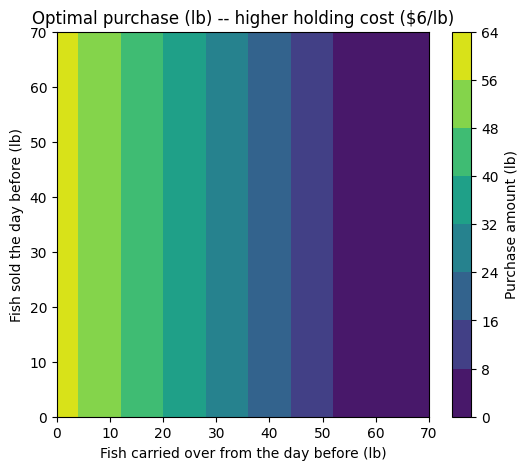

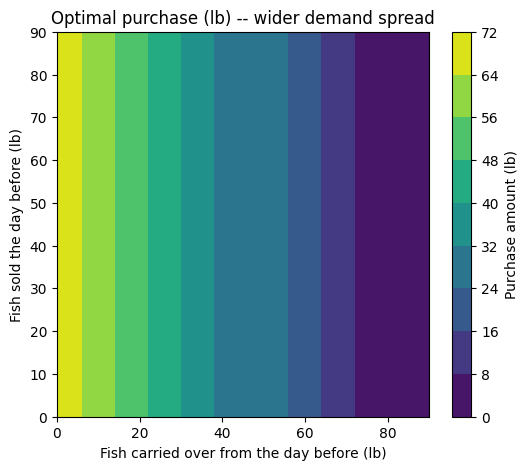

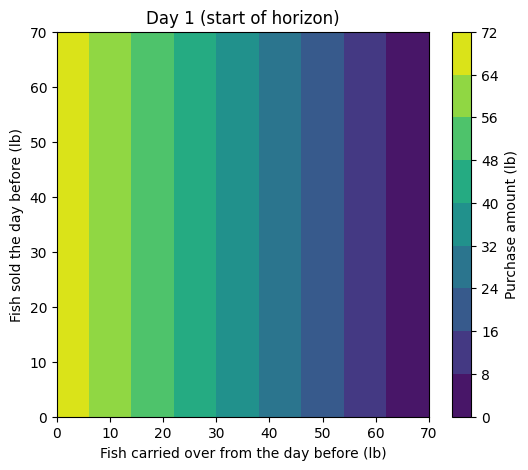

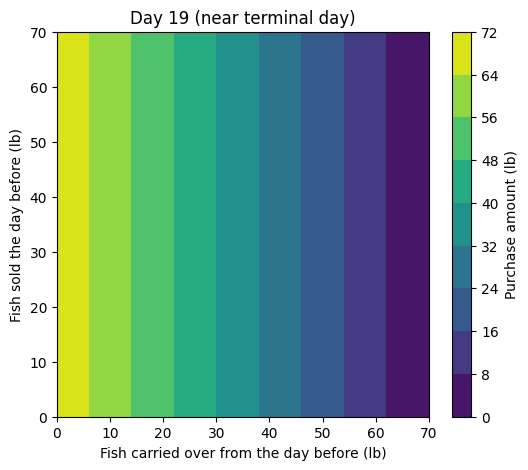

In [6]:
# Example: higher holding cost -> more conservative ordering
result_highhold = solve_sushi_dp(holdcost=6)
_ = plot_policy(result_highhold, itime=0,
                 title='Optimal purchase (lb) -- higher holding cost ($6/lb)')

# Example: wider demand spread -> steeper dependence on carryover
result_widedemand = solve_sushi_dp(demand_vals=50 + 10*np.arange(-4, 5),
                                    prob=np.ones(9))
_ = plot_policy(result_widedemand, itime=0,
                 title='Optimal purchase (lb) -- wider demand spread')

# Example: edge-of-horizon effect (day T-1 vs a mid-horizon day)
result_chain2 = solve_sushi_dp(T=20)
_ = plot_policy(result_chain2, itime=0,  title='Day 1 (start of horizon)')
_ = plot_policy(result_chain2, itime=18, title='Day 19 (near terminal day)')
